In [1]:
# pip install pyscipopt   # if you have SCIP available
import dwave_networkx as dnx
import torch
import torch.nn as nn
import torch.nn.functional as F
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import random
from skimage.transform import resize
import pandas as pd
import os
from torchvision import datasets, transforms
import dwave.system
import dimod
from dwave.samplers import SimulatedAnnealingSampler

from pyscipopt import Model, quicksum
import numpy as np
import dimod
import itertools
from pyomo.environ import ConcreteModel, Var, Constraint, Objective, SolverFactory, NonNegativeIntegers, Binary, summation, value, RangeSet

In [2]:
# Analysis HELPERS
def analyze_zephyr_layout(G, K, save_to_csv=True):
    """
    Detailed analysis of Zephyr graph structure.
    Returns DataFrame with node positions, degrees, and identifies edge nodes.
    """
    import pandas as pd
    
    # Get Zephyr layout positions
    try:
        pos = dnx.zephyr_layout(G)
    except:
        print("⚠️ Using spring layout fallback")
        pos = nx.spring_layout(G, seed=42)
    
    # Collect node data
    node_data = []
    for node in G.nodes():
        x, y = pos[node]
        deg = G.degree(node)
        
        # Calculate distance from center
        center_x = sum(p[0] for p in pos.values()) / len(pos)
        center_y = sum(p[1] for p in pos.values()) / len(pos)
        dist_from_center = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        
        # Identify if it's an edge node 
        is_edge = (deg < 8) or (dist_from_center > np.percentile([
            np.sqrt((pos[n][0] - center_x)**2 + (pos[n][1] - center_y)**2) 
            for n in G.nodes()
        ], 80))
        
        node_data.append({
            'node': node,
            'x': x,
            'y': y,
            'degree': deg,
            'dist_from_center': dist_from_center,
            'is_edge': is_edge
        })
    
    df = pd.DataFrame(node_data)
    
    # Sort by different criteria
    print("\n Top 20 nodes by degree ")
    print(df.nlargest(20, 'degree')[['node', 'degree', 'x', 'y', 'dist_from_center']])
    
    print("\n Bottom 20 nodes by degree (edge candidates) ")
    print(df.nsmallest(20, 'degree')[['node', 'degree', 'x', 'y', 'dist_from_center']])
    
    print("\n 20 nodes farthest from center ")
    print(df.nlargest(20, 'dist_from_center')[['node', 'degree', 'x', 'y', 'dist_from_center']])
    
    print("\nDegree distribution ")
    print(df['degree'].value_counts().sort_index())
    
    print(f"\nEdge node statistics")
    edge_nodes = df[df['is_edge']]
    print(f"  Edge nodes identified: {len(edge_nodes)}")
    print(f"  Avg degree (edge): {edge_nodes['degree'].mean():.2f}")
    print(f"  Avg degree (center): {df[~df['is_edge']]['degree'].mean():.2f}")
    
    if save_to_csv:
        filename = f"zephyr_k{K}_node_analysis.csv"
        df.to_csv(filename, index=False)
        print(f"\n Saved full analysis to {filename}")
    
    return df



def visualize_node_assignment_on_zephyr(G, visible_nodes, hidden_nodes, title="Node Assignment"):
    """
    Visualize which nodes are visible/hidden overlaid on Zephyr structure.
    Color by degree and assignment.
    """
    try:
        pos = dnx.zephyr_layout(G)
    except:
        pos = nx.spring_layout(G, seed=42)
    
    # Prepare colors and sizes
    colors = []
    sizes = []
    labels_to_show = {}
    
    for node in G.nodes():
        deg = G.degree(node)
        
        if node in visible_nodes:
            colors.append('red')
            sizes.append(100 + deg * 10)  # Larger = higher degree
        elif node in hidden_nodes:
            colors.append('blue')
            sizes.append(100 + deg * 10)
        else:
            colors.append('gray')
            sizes.append(50)
        
        # Label only low-degree nodes for debugging
        if deg < 6:
            labels_to_show[node] = f"{node}\n(d={deg})"
    
    plt.figure(figsize=(16, 12))
    
    # Draw all edges lightly
    nx.draw_networkx_edges(G, pos, alpha=0.1, edge_color='lightgray', width=0.5)
    
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=sizes, alpha=0.7)
    
    # Draw labels for low-degree nodes
    nx.draw_networkx_labels(G, pos, labels=labels_to_show, font_size=6)
    
    # Legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='red', 
               markersize=10, label='Visible'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', 
               markersize=10, label='Hidden'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', 
               markersize=10, label='Removed')
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    
    plt.title(f"{title}\n(Node size ∝ degree, labels show degree < 6)")
    plt.axis('off')
    plt.tight_layout()
    plt.show()




In [ ]:
# Pixel-Visible node assignment (heuristic)

def compute_pixel_importance(grid_shape=(12, 12)):
    """
    Assign importance scores to pixels based on distance from center.
    Returns: importance_map (grid_shape), flat_importance (flattened)
    """
    rows, cols = grid_shape
    center_r, center_c = rows / 2, cols / 2
    
    importance_map = np.zeros(grid_shape)
    for r in range(rows):
        for c in range(cols):
            # Gaussian-like importance: higher at center
            dist = np.sqrt((r - center_r)**2 + (c - center_c)**2)
            importance_map[r, c] = np.exp(-dist**2 / (2 * (rows/4)**2))
    
    # Normalize to [0, 1]
    importance_map = importance_map / importance_map.max()
    flat_importance = importance_map.flatten()
    
    return importance_map, flat_importance

def compute_pixel_adjacency(grid_shape=(12, 12)):
    """
    Build adjacency list for pixels (8-connectivity or 4-connectivity).
    Returns: dict mapping pixel_id -> set of neighbor pixel_ids
    """
    rows, cols = grid_shape
    pixel_adj = {}
    
    for r in range(rows):
        for c in range(cols):
            pid = r * cols + c
            neighbors = set()
            
            # 4-connectivity (up, down, left, right)
            for dr, dc in [(-1,0), (1,0), (0,-1), (0,1)]:
                nr, nc = r + dr, c + dc
                if 0 <= nr < rows and 0 <= nc < cols:
                    neighbors.add(nr * cols + nc)
            
            # Optional: add diagonal neighbors for 8-connectivity
            # for dr, dc in [(-1,-1), (-1,1), (1,-1), (1,1)]:
            #     nr, nc = r + dr, c + dc
            #     if 0 <= nr < rows and 0 <= nc < cols:
            #         neighbors.add(nr * cols + nc)
            
            pixel_adj[pid] = neighbors
    
    return pixel_adj

def assign_pixels_to_nodes_heuristic(G, num_pixels=144, grid_shape=(12, 12)):
    """
    Heuristically assign graph nodes to pixels, prioritizing:
    1. High-degree nodes for center pixels (high importance)
    2. Spatially close pixels should map to graph-neighboring nodes
    
    Returns: pixel_to_node (dict: pixel_id -> node_id)
    """
    importance_map, flat_importance = compute_pixel_importance(grid_shape)
    pixel_adj = compute_pixel_adjacency(grid_shape)
    
    # Sort pixels by importance (center first)
    pixel_order = np.argsort(-flat_importance)  # Descending importance
    
    # Sort nodes by degree (high degree first)
    nodes = sorted(G.nodes())
    node_degrees = {n: G.degree(n) for n in nodes}
    node_order = sorted(nodes, key=lambda n: -node_degrees[n])
    
    pixel_to_node = {}
    node_to_pixel = {}
    used_nodes = set()
    
    # Greedy assignment with spatial awareness
    for pixel_id in pixel_order:
        if len(pixel_to_node) >= num_pixels:
            break
        
        # Get already-assigned neighbor pixels
        assigned_neighbors = [pixel_to_node[nb] for nb in pixel_adj[pixel_id] 
                             if nb in pixel_to_node]
        
        # Find candidate nodes that are:
        # 1. Not yet used
        # 2. Preferably connected to nodes of neighbor pixels
        candidate_nodes = [n for n in node_order if n not in used_nodes]
        
        if assigned_neighbors:
            # Score nodes by how many graph-neighbors they share with assigned pixel neighbors
            def score_node(node):
                graph_neighbors = set(G.neighbors(node))
                overlap = len(graph_neighbors & set(assigned_neighbors))
                return overlap + node_degrees[node] * 0.1  # Slight degree bonus
            
            candidate_nodes.sort(key=score_node, reverse=True)
        
        # Assign best candidate
        chosen_node = candidate_nodes[0]
        pixel_to_node[pixel_id] = chosen_node
        node_to_pixel[chosen_node] = pixel_id
        used_nodes.add(chosen_node)
    
    print(f"Assigned {len(pixel_to_node)} pixels to nodes")
    print(f"  Center pixel (0,0) -> node {pixel_to_node.get(0, 'N/A')} with degree {node_degrees.get(pixel_to_node.get(0, -1), 0)}")
    
    return pixel_to_node, node_to_pixel


def preprocess_graph(G, V_target, H_target):
    """Remove low-value nodes before optimization to reduce problem size."""
    nodes = sorted(G.nodes())
    n = len(nodes)
    
    # Calculate how many nodes to remove
    target_total = V_target + H_target
    nodes_to_remove = n - target_total
    
    # Remove lowest-degree nodes iteratively
    G_work = G.copy()
    removed = 0
    
    while removed < nodes_to_remove:
        degrees = [(node, G_work.degree(node)) for node in G_work.nodes()]
        degrees.sort(key=lambda x: x[1])
        
        # Remove lowest degree node
        node_to_remove = degrees[0][0]
        G_work.remove_node(node_to_remove)
        removed += 1
        
        if removed % 50 == 0:
            print(f"  Removed {removed}/{nodes_to_remove} nodes...")
    
    print(f"Preprocessed: {n} → {G_work.number_of_nodes()} nodes")
    return G_work


def remove_edge_nodes(G, min_degree=6):
    """
    Remove poorly-connected edge nodes from Zephyr graph.
    Zephyr K=3 has max degree ~8, so nodes with degree < 6 are edges.
    """
    G_clean = G.copy()
    nodes_to_remove = []
    
    for node in G.nodes():
        if G.degree(node) < min_degree:
            nodes_to_remove.append(node)
    
    print(f"Removing {len(nodes_to_remove)} edge nodes (degree < {min_degree})")
    G_clean.remove_nodes_from(nodes_to_remove)
    
    # Relabel nodes to be consecutive
    G_clean = nx.convert_node_labels_to_integers(G_clean, ordering='sorted')
    
    print(f"  Original nodes: {G.number_of_nodes()}")
    print(f"  Cleaned nodes: {G_clean.number_of_nodes()}")
    print(f"  Degree distribution after cleaning: min={min(dict(G_clean.degree()).values())}, max={max(dict(G_clean.degree()).values())}")
    
    return G_clean


# Analyze hidden-hidden connectivity
def analyze_fusion_potential(G, nodes, V_target):
    """Check how many fusions are theoretically possible."""
    # Assume first V_target nodes will be visible (worst case for hidden connectivity)
    hidden_nodes = nodes[V_target:]
    
    # Build subgraph of just hidden nodes
    H_subgraph = G.subgraph(hidden_nodes)
    
    # Count connected components
    components = list(nx.connected_components(H_subgraph))
    num_components = len(components)
    
    # Maximum fusions = |hidden_nodes| - |components|
    # (you can't fuse nodes across disconnected components)
    max_fusions_possible = len(hidden_nodes) - num_components
    
    print(f"\n Fusion Potential Analysis ")
    print(f"  Hidden nodes: {len(hidden_nodes)}")
    print(f"  Connected components in hidden subgraph: {num_components}")
    print(f"  Maximum fusions possible: {max_fusions_possible}")
    print(f"  Required fusions: {len(hidden_nodes) - H_target}")
    print(f"  Gap: {max_fusions_possible - (len(hidden_nodes) - H_target)}")
    
    # Component sizes
    comp_sizes = sorted([len(c) for c in components], reverse=True)
    print(f"  Component sizes: {comp_sizes[:10]}...")
    
    return max_fusions_possible


def apply_fusions_to_graph_clean(G_original, x_vals, z_vals):
    """
    Wrapper that ensures clean integer node IDs throughout.
    """
    # First, ensure input graph has integer nodes
    if not all(isinstance(n, int) for n in G_original.nodes()):
        print("⚠️ Input graph has non-integer nodes, relabeling...")
        mapping = {old: i for i, old in enumerate(sorted(G_original.nodes(), key=str))}
        G_original = nx.relabel_nodes(G_original, mapping)
        
        # Update x_vals and z_vals with new node IDs
        x_vals_new = {mapping.get(k, k): v for k, v in x_vals.items() if k in mapping}
        z_vals_new = {}
        for (k, l), v in z_vals.items():
            if k in mapping and l in mapping:
                k_new, l_new = mapping[k], mapping[l]
                z_vals_new[(min(k_new, l_new), max(k_new, l_new))] = v
        
        x_vals = x_vals_new
        z_vals = z_vals_new
    
    # Now apply fusions (using previous function logic)
    G = G_original.copy()
    nodes = sorted(G.nodes())  # Now safe to sort - all integers
    
    visible_nodes_original = set(i for i in nodes if x_vals.get(i, 0) > 0.5)
    hidden_nodes_original = set(i for i in nodes if x_vals.get(i, 0) <= 0.5)
    
    print(f"\n=== Pre-Fusion Status ===")
    print(f"  Visible nodes: {len(visible_nodes_original)}")
    print(f"  Hidden nodes: {len(hidden_nodes_original)}")
    
    # Union-Find for hidden nodes only
    parent = {i: i for i in hidden_nodes_original}
    
    def find(i):
        if i not in parent:
            return i
        if parent[i] != i:
            parent[i] = find(parent[i])
        return parent[i]
    
    def union(i, j):
        if i not in hidden_nodes_original or j not in hidden_nodes_original:
            return False
        pi, pj = find(i), find(j)
        if pi != pj:
            parent[pj] = pi
            return True
        return False
    
    fusions_applied = 0
    for (k, l), val in z_vals.items():
        if val > 0.5:
            if union(k, l):
                fusions_applied += 1
    
    print(f"  Fusions applied: {fusions_applied}")
    
    # Create fusion groups
    fusion_groups = {}
    for h_node in hidden_nodes_original:
        root = find(h_node)
        if root not in fusion_groups:
            fusion_groups[root] = []
        fusion_groups[root].append(h_node)
    
    # Contract graph
    G_contracted = G.copy()
    old_to_new = {}
    
    # Visible nodes unchanged
    for v in visible_nodes_original:
        old_to_new[v] = v
    
    # Fuse hidden nodes
    for root, group in fusion_groups.items():
        if len(group) > 1:
            representative = min(group)
            for node in group:
                old_to_new[node] = representative
            
            all_neighbors = set()
            for node in group:
                if node in G_contracted:
                    all_neighbors.update(G_contracted.neighbors(node))
            all_neighbors -= set(group)
            
            for node in group:
                if node != representative and node in G_contracted:
                    G_contracted.remove_node(node)
            
            for neighbor in all_neighbors:
                neighbor_mapped = old_to_new.get(neighbor, neighbor)
                if neighbor_mapped != representative:
                    G_contracted.add_edge(representative, neighbor_mapped)
        else:
            old_to_new[group[0]] = group[0]
    
    visible_nodes_final = sorted(visible_nodes_original)
    hidden_nodes_final = sorted(set(old_to_new[h] for h in hidden_nodes_original))
    
    # **KEY FIX: Relabel to consecutive integers**
    print("\n=== Relabeling to consecutive integers ===")
    all_nodes_ordered = visible_nodes_final + hidden_nodes_final
    relabel_map = {old_id: new_id for new_id, old_id in enumerate(all_nodes_ordered)}
    
    G_contracted = nx.relabel_nodes(G_contracted, relabel_map)
    visible_nodes_final = [relabel_map[v] for v in visible_nodes_final]
    hidden_nodes_final = [relabel_map[h] for h in hidden_nodes_final]
    
    print(f"  Relabeled nodes: 0 to {len(G_contracted.nodes())-1}")
    print(f"  Visible IDs: 0 to {len(visible_nodes_final)-1}")
    print(f"  Hidden IDs: {len(visible_nodes_final)} to {len(all_nodes_ordered)-1}")
    
    return G_contracted, visible_nodes_final, hidden_nodes_final, old_to_new


def postprocess_fuse_hidden(G_contracted, visible_nodes, hidden_nodes, H_target):
    """
    Stage 2: Greedily fuse ONLY hidden nodes to reach target.
    VISIBLE NODES ARE NEVER TOUCHED.
    """
    print(f"\n=== POST-PROCESSING: Fuse {len(hidden_nodes)} → {H_target} hidden nodes ===")
    
    if len(hidden_nodes) <= H_target:
        print(f"  Already at or below target!")
        return G_contracted, visible_nodes, hidden_nodes
    
    G_work = G_contracted.copy()
    visible_set = set(visible_nodes)  # Track which nodes are visible
    hidden_remaining = set(hidden_nodes)
    
    fusions_needed = len(hidden_nodes) - H_target
    fusions_done = 0
    
    while fusions_done < fusions_needed and len(hidden_remaining) > H_target:
        # Find lowest-degree HIDDEN node
        hidden_degrees = [(n, G_work.degree(n)) for n in hidden_remaining]
        if not hidden_degrees:
            break
        hidden_degrees.sort(key=lambda x: x[1])
        
        node1 = hidden_degrees[0][0]
        
        # Find its lowest-degree HIDDEN neighbor (don't fuse with visible!)
        hidden_neighbors = [nb for nb in G_work.neighbors(node1) 
                           if nb in hidden_remaining and nb != node1]
        
        if not hidden_neighbors:
            # Isolated hidden node - just remove it
            G_work.remove_node(node1)
            hidden_remaining.discard(node1)
            fusions_done += 1
            continue
        
        node2 = min(hidden_neighbors, key=lambda n: G_work.degree(n))
        
        # Contract node2 INTO node1 (node1 survives, node2 disappears)
        G_work = nx.contracted_nodes(G_work, node1, node2, self_loops=False)
        hidden_remaining.discard(node2)
        fusions_done += 1
        
        if fusions_done % 10 == 0:
            print(f"  Progress: {fusions_done}/{fusions_needed} fusions")
    
    # Final counts
    final_hidden = list(hidden_remaining)
    final_visible = [v for v in visible_nodes if v in G_work.nodes()]
    
    print(f"✓ Post-processing complete:")
    print(f"  Visible: {len(final_visible)} (target: {len(visible_nodes)})")
    print(f"  Hidden: {len(final_hidden)} (target: {H_target})")
    print(f"  Total nodes: {G_work.number_of_nodes()}")
    
    # Verify visible count
    if len(final_visible) != len(visible_nodes):
        print(f"  WARNING: Lost {len(visible_nodes) - len(final_visible)} visible nodes!")
    
    return G_work, final_visible, final_hidden



def visualize_contracted_graph(G_contracted, visible_nodes, hidden_nodes, 
                               use_zephyr_layout=True):
    """
    Visualize the contracted graph showing visible vs hidden nodes.
    """
    # Create x_sol format for compatibility with analyze_maxcut
    x_sol = {}
    for node in G_contracted.nodes():
        x_sol[node] = 1 if node in visible_nodes else 0
    
    # Count cross-edges (visible-hidden connections)
    cross_edges = []
    for u, v in G_contracted.edges():
        if x_sol[u] != x_sol[v]:
            cross_edges.append((u, v))
    
    print(f" Cross-edges (V-H): {len(cross_edges)} out of {G_contracted.number_of_edges()}")
    print(f" Visible nodes: {len(visible_nodes)}")
    print(f" Hidden nodes: {len(hidden_nodes)}")
    
    # Visualize
    if use_zephyr_layout:
        # Use spring layout since Zephyr layout won't work after contraction
        pos = nx.spring_layout(G_contracted, seed=42, k=0.5)
    else:
        pos = nx.spring_layout(G_contracted, seed=42)
    
    node_colors = ['red' if node in visible_nodes else 'blue' 
                   for node in G_contracted.nodes()]
    
    plt.figure(figsize=(12, 8))
    nx.draw_networkx_nodes(G_contracted, pos, node_color=node_colors, 
                          node_size=50, alpha=0.8)
    nx.draw_networkx_edges(G_contracted, pos, edge_color='lightgray', 
                          alpha=0.3, width=0.5)
    nx.draw_networkx_edges(G_contracted, pos, edgelist=cross_edges, 
                          edge_color='green', alpha=0.6, width=1.0)
    
    # Add legend
    red_patch = plt.Line2D([0], [0], marker='o', color='w', 
                           markerfacecolor='red', markersize=10, label='Visible')
    blue_patch = plt.Line2D([0], [0], marker='o', color='w', 
                            markerfacecolor='blue', markersize=10, label='Hidden')
    green_line = plt.Line2D([0], [0], color='green', linewidth=2, 
                            label='V-H edges')
    plt.legend(handles=[red_patch, blue_patch, green_line], loc='upper right')
    
    plt.title(f"Contracted Graph: {len(visible_nodes)} Visible, "
              f"{len(hidden_nodes)} Hidden\n"
              f"{len(cross_edges)} cross-edges")
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    return x_sol


# Relabel graph nodes to be consecutive: visible first (0 to V-1), then hidden (V to V+H-1)

def relabel_for_training(G_contracted, visible_nodes, hidden_nodes):
    """
    Relabel graph so visible nodes are [0, num_visible-1] 
    and hidden nodes are [num_visible, num_visible+num_hidden-1].
    """
    old_to_new = {}
    
    # Sort visible nodes (handle mixed types)
    try:
        visible_sorted = sorted(visible_nodes)
    except TypeError:
        # Mixed types - convert all to strings for sorting, then use original
        visible_sorted = sorted(visible_nodes, key=str)
    
    # Sort hidden nodes (handle mixed types)
    try:
        hidden_sorted = sorted(hidden_nodes)
    except TypeError:
        hidden_sorted = sorted(hidden_nodes, key=str)
    
    # Visible nodes get IDs 0 to len(visible_nodes)-1
    for new_id, old_id in enumerate(visible_sorted):
        old_to_new[old_id] = new_id
    
    # Hidden nodes get IDs starting from len(visible_nodes)
    offset = len(visible_nodes)
    for new_id, old_id in enumerate(hidden_sorted):
        old_to_new[old_id] = offset + new_id
    
    # Relabel graph
    G_relabeled = nx.relabel_nodes(G_contracted, old_to_new, copy=True)
    
    # New node lists (now all integers)
    visible_new = list(range(len(visible_nodes)))
    hidden_new = list(range(len(visible_nodes), len(visible_nodes) + len(hidden_nodes)))
    
    print(f"Relabeling complete:")
    print(f"  Old node types: {set(type(n).__name__ for n in G_contracted.nodes())}")
    print(f"  New node IDs: all integers [0, {len(G_relabeled.nodes())-1}]")
    
    return G_relabeled, visible_new, hidden_new, old_to_new


In [23]:

def build_and_solve(K, V_target, H_target, tee=False, initial_visible_assignment=None): # new parameter initial_visible_assignment
    # Build Zephyr graph
    G = dnx.zephyr_graph(K)
    nodes = sorted(G.nodes())
    n = len(nodes)
    node_index = {i: idx for idx, i in enumerate(nodes)}

    edges = sorted(set((min(u, v), max(u, v)) for u, v in G.edges()))

    adj = {i: set() for i in nodes}
    for u, v in edges:
        adj[u].add(v)
        adj[v].add(u)

    P = edges.copy()
    # P = [(i, j) for i in nodes for j in nodes if i < j]  # All pairs

    triples = []
    for (k, l) in P:
        common_neighbors = set(adj[k]).intersection(adj[l])
        for i in common_neighbors:
            triples.append((i, k, l))
    triples = list(set(triples))

    if not (0 <= V_target <= n):
        raise ValueError("V_target out of range")
    if not (0 <= H_target <= n):
        raise ValueError("H_target out of range")
    f_required = (n - V_target) - H_target
    if f_required < 0:
        raise ValueError(f"Impossible targets: need nonnegative fusions, got {f_required}")

    
    # Build SCIP model
    
    m = Model("NodeLabelOptimization")

    #  Variables 
    relax = False  # <-- toggle

    x = {i: m.addVar(vtype="C" if relax else "B", lb=0, ub=1, name=f"x_{i}") for i in nodes}
    z = {p: m.addVar(vtype="C" if relax else "B", lb=0, ub=1, name=f"z_{p[0]}_{p[1]}") for p in P}
    y = {e: m.addVar(vtype="C" if relax else "B", lb=0, ub=1, name=f"y_{e[0]}_{e[1]}") for e in edges}
    u = {t: m.addVar(vtype="C" if relax else "B", lb=0, ub=1, name=f"u_{t[0]}_{t[1]}_{t[2]}") for t in triples}
    t_var = m.addVar(vtype="I", lb=0, name="t")

    # If initial visible assignment provided, use it as starting point
    if initial_visible_assignment is not None and not relax:
        initial_visible = set(initial_visible_assignment.values())
        print(f"Creating warm start with {len(initial_visible)} pre-assigned visible nodes")
        
        # Create a heuristic solution
        heur_sol = m.createPartialSol()
        
        # Set x variables based on initial assignment
        for i in nodes:
            if i in initial_visible:
                m.setSolVal(heur_sol, x[i], 1.0)
            else:
                m.setSolVal(heur_sol, x[i], 0.0)
        
        # Don't set z variables yet - let solver figure out fusions
        # Add the partial solution
        m.addSol(heur_sol, free=True)  # free=True allows solver to modify it
        print("Warm start added")

    
    # Constraints
    
    # 1) Visible node count
    m.addCons(quicksum(x[i] for i in nodes) == V_target, "visible_count")

    # # 2) Hidden target: sum x_i + sum z_kl = n - H_target
    m.addCons(quicksum(x[i] for i in nodes) + quicksum(z[p] for p in P) == n - H_target, "hidden_target")

    # # 2b) After fusions:
    # # - V-V fusions reduce visible count by 1 (two visible -> one visible)
    # # - H-H fusions reduce hidden count by 1 (two hidden -> one hidden)
    # # Let: vv_fusions = sum of z[(k,l)] where both k,l are initially visible
    # #      hh_fusions = sum of z[(k,l)] where both k,l are initially hidden

    # vv_fusion_sum = quicksum(z[(k,l)] * x[k] * x[l] for (k,l) in P)  # Approximate
    # hh_fusion_sum = quicksum(z[(k,l)] * (1-x[k]) * (1-x[l]) for (k,l) in P)  # Approximate

    # # Visible after fusion: V_target (initial) - vv_fusions
    # # Hidden after fusion: (n - V_target) (initial) - hh_fusions
    # # Constraint: Hidden after fusion = H_target
    # # So: (n - V_target) - hh_fusions = H_target
    # # Therefore: hh_fusions = n - V_target - H_target

    # m.addCons(hh_fusion_sum == n - V_target - H_target, "hidden_target_with_fusion")

    # Debug: Is the hidden target even achievable?
    print(f"\nFeasibility check:")
    print(f"  Total nodes: {n}")
    print(f"  Target visible: {V_target}")
    print(f"  Target hidden: {H_target}")
    print(f"  Required fusions: {n - V_target - H_target}")
    print(f"  Maximum possible fusions (with matching): {len([i for i in nodes if len(adj[i]) > 0])}")

    # Debug: check if basic constraints are consistent
    m.addCons(quicksum(x[i] for i in nodes) + quicksum(z[p] for p in P) == n - H_target, "hidden_target")
    print(f" Added constraint: sum(x) + sum(z) = {n - H_target}")
    print(f"  This means: {V_target} visible + {n - V_target - H_target} fusions → {H_target} hidden")

    
    
    # # 3) Fusion only among hidden nodes
    for (k, l) in P:
        m.addCons(z[(k, l)] <= 1 - x[k], f"fusion1_{k}_{l}")
        m.addCons(z[(k, l)] <= 1 - x[l], f"fusion2_{k}_{l}")

    # # 3b) Fusion rules: Allow V-V fusion, but result must stay visible
    # # If both visible: fusion creates a new visible node
    # # If both hidden: fusion creates a new hidden node
    # # No V-H fusion (would be ambiguous)

    # # Add variable to track if fusion result is visible
    # z_result_visible = {p: m.addVar(vtype="C" if relax else "B", lb=0, ub=1, 
    #                                 name=f"zv_{p[0]}_{p[1]}") for p in P}

    # for (k, l) in P:
    #     # If both k,l are visible, fusion result must be visible
    #     # z_result_visible[(k,l)] >= x[k] + x[l] - 1
    #     m.addCons(z_result_visible[(k, l)] >= x[k] + x[l] - 1, f"vv_fusion1_{k}_{l}")
        
    #     # If fusion happens and both visible, result is visible
    #     # z_result_visible[(k,l)] <= (x[k] + x[l])/2 + M*(1-z[(k,l)])
    #     # Simplified: if z=1 and both x=1, then z_result_visible=1
    #     m.addCons(z_result_visible[(k, l)] <= x[k], f"vv_fusion2_{k}_{l}")
    #     m.addCons(z_result_visible[(k, l)] <= x[l], f"vv_fusion3_{k}_{l}")
        
    #     # No V-H fusion: if one is visible and one hidden, can't fuse
    #     # z[(k,l)] <= 1 - |x[k] - x[l]|
    #     # Use y[(k,l)] which already computes |x[k] - x[l]|
    #     if (min(k,l), max(k,l)) in y:
    #         m.addCons(z[(k, l)] <= 1 - y[(min(k, l), max(k, l))], f"no_vh_fusion_{k}_{l}")

    # # 4) Matching constraint: node participates in ≤ 1 fusion
    # for i in nodes:
    #     nbrs = [(min(i, j), max(i, j)) for j in adj[i]]
    #     if nbrs:
    #         m.addCons(quicksum(z[p] for p in nbrs) <= 1 - x[i], f"match_{i}")

    # 5) Linearize y_ij = |x_i - x_j|
    for (i, j) in edges:
        m.addCons(y[(i, j)] >= x[i] - x[j])
        m.addCons(y[(i, j)] >= x[j] - x[i])
        m.addCons(y[(i, j)] <= x[i] + x[j])
        m.addCons(y[(i, j)] <= 2 - (x[i] + x[j]))

    # 6) Linearize u_{i,kl} = x_i * z_{kl}
    for (i, k, l) in triples:
        m.addCons(u[(i, k, l)] <= x[i])
        m.addCons(u[(i, k, l)] <= z[(k, l)])
        m.addCons(u[(i, k, l)] >= x[i] + z[(k, l)] - 1)

    # 7) Maximin constraint: t <= c_i + M*x_i
    max_deg = max(len(adj[i]) for i in nodes)
    M = max_deg
    for i in nodes:
        c_i0 = quicksum(y[(min(i, j), max(i, j))] for j in adj[i])
        losses = quicksum(u[t] for t in triples if t[0] == i)
        c_i_expr = c_i0 - losses
        m.addCons(t_var <= c_i_expr + M * x[i], f"maximin_{i}")

    # 8) Upper bound for t
    m.addCons(t_var <= max_deg, "t_upper")

    # 8b) Lower bound for t based on empirical evidence
    m.addCons(t_var >= 4, "t_lower_bound")
    print("Added constraint: t >= 4 (empirically achievable)")


    # Objective: maximize t
    m.setObjective(t_var, "maximize")

    # m.setObjective(quicksum(z[p] for p in P), "maximize")  # Just maximize fusions

   
    # Solve
    m.setParam("limits/time", 60.0)
    m.setParam("display/verblevel", 5 if tee else 0)
    m.setParam("limits/gap", 0.0)

    print(f"K={K}, n={n}, V_target={V_target}, H_target={H_target}")
    print(f"f_required = {(n - V_target) - H_target}")
    print(f"Max possible fusions (n/2) = {n//2}")
    print(f"Total edges = {len(edges)}")

    # Debug: check if basic constraints are consistent
    print("\nPre-solve check:")
    print(f"  Nodes: {len(nodes)}")
    print(f"  V_target: {V_target}")
    print(f"  H_target: {H_target}")
    print(f"  Required fusions: {n - V_target - H_target}")
    print(f"  Available fusion pairs: {len(P)}")

    if (n - V_target - H_target) > len(P):
        print("  WARNING: Not enough fusion pairs available!")
    m.optimize()

    status = m.getStatus()
    print(f"Solver status: {status}")

    # Debug
    # actual_fusions = sum(1 for val in z_vals.values() if val > 0.5)
    # print(f"\nConstraint check:")
    # print(f"  sum(x) = {sum(x_vals.values())}")
    # print(f"  sum(z) = {sum(z_vals.values())} (actual: {actual_fusions} binary)")
    # print(f"  sum(x) + sum(z) = {sum(x_vals.values()) + sum(z_vals.values())}")
    # print(f"  Target: {n - H_target}")
    # print(f"  Difference: {abs(sum(x_vals.values()) + sum(z_vals.values()) - (n - H_target))}")

    # Extract results
   
    # after m.optimize() and checking m.getNSols() > 0
    sol = m.getBestSol()

    # Time limit reached without feasible solution
    if sol is None:
        print(" NO SOLUTION FOUND: Solver hit time limit before finding feasible solution.")
        print("   Returning empty solution:")
        return {
            "model": m,
            "x": {i: 0.0 for i in nodes},
            "z": {p: 0.0 for p in P},
            "y": {e: 0.0 for e in edges},
            "u": {t: 0.0 for t in triples},
            "t": 0.0,
            "c0": {i: 0.0 for i in nodes},
            "losses": {i: 0.0 for i in nodes},
            "c_eff": {i: 0.0 for i in nodes},
            "G_original": G,
            "G_contracted": G.copy(),
            "fused_map": {}
        }

    # raw floats
    x_vals = {i: m.getSolVal(sol, x[i]) for i in nodes}
    z_vals = {p: m.getSolVal(sol, z[p]) for p in P}
    y_vals = {e: m.getSolVal(sol, y[e]) for e in edges}
    u_vals = {t: m.getSolVal(sol, u[t]) for t in triples}
    t_val = m.getSolVal(sol, t_var)

    # quick summaries
    print("SUM x (float) =", sum(x_vals.values()))
    print("SUM z (float) =", sum(z_vals.values()))
    print("SUM y (float) =", sum(y_vals.values()))
    print("t (float) =", t_val)

    # show top nonzero vars
    print("Top x (nonzero):", [(i, round(x_vals[i],3)) for i in nodes if x_vals[i] > 1e-6][:20])
    print("Top z (nonzero):", [(p, round(z_vals[p],3)) for p in P if z_vals[p] > 1e-6][:20])
    print("Top y (nonzero):", [(e, round(y_vals[e],3)) for e in edges if y_vals[e] > 1e-6][:20])

    # Compute effective c_i
    c0 = {}
    losses = {}
    c_eff = {}
    for i in nodes:
        nbrs = [(min(i, j), max(i, j)) for j in adj[i]]
        c0[i] = sum(y_vals.get(p, 0.0) for p in nbrs)
        losses[i] = sum(u_vals.get(t, 0.0) for t in triples if t[0] == i)
        c_eff[i] = c0[i] - losses[i]

  
   
    # Build contracted graph (apply fusions)
    G_contracted = G.copy()
    fused_map = {}  # maps original node to final representative

    # Group fusions by connected components
    fusion_edges = [(k, l) for (k, l), val in z_vals.items() if val > 0.99]  # use threshold for float tolerance

    # Build fusion graph to find connected components
    fusion_graph = nx.Graph()
    fusion_graph.add_nodes_from(nodes)
    fusion_graph.add_edges_from(fusion_edges)

    # Each connected component gets fused into one node
    for component in nx.connected_components(fusion_graph):
        if len(component) == 1:
            continue  # singleton, no fusion needed
        
        # Pick representative (eg, smallest node)
        rep = min(component)
        rep_name = "_".join(map(str, sorted(component)))
        
        # Collect all neighbors from all nodes in component
        all_neighbors = set()
        for node in component:
            if node in G_contracted:
                all_neighbors.update(G_contracted.neighbors(node))
        
        # Remove nodes being fused from neighbor set
        all_neighbors -= component
        
        # Add new representative node
        if rep_name not in G_contracted:
            G_contracted.add_node(rep_name)
        
        # Connect representative to all external neighbors
        for nb in all_neighbors:
            if nb not in component:  # don't self-loop
                G_contracted.add_edge(rep_name, nb)
        
        # Remove original nodes
        for node in component:
            if node in G_contracted:
                G_contracted.remove_node(node)
            fused_map[node] = rep_name

    print(f"Objective t = {t_val}")
    print("Visible nodes (x_i=1):", [i for i, xv in x_vals.items() if xv == 1])
    print("Fusions (z_{k,l}=1):", [p for p, zv in z_vals.items() if zv == 1])
    print("Effective cross-edges per node (c_eff):")
    for i in nodes:
        print(f" node {i}: x={x_vals[i]}, c0={c0[i]}, losses={losses[i]}, c_eff={c_eff[i]}")

    return {
        "model": m,
        "x": x_vals,
        "z": z_vals,
        "y": y_vals,
        "u": u_vals,
        "t": t_val,
        "c0": c0,
        "losses": losses,
        "c_eff": c_eff,
        "G_original": G,
        "G_contracted": G_contracted,
        "fused_map": fused_map
    }


In [50]:
K = 3
G = dnx.zephyr_graph(K)
n = G.number_of_nodes()
nodes = sorted(G.nodes())
print('K =', K, 'n =', n, 'n/K =', n/K, 'n/(32*K^2) =', n/(32*K**2+16*K))
print("Toal number of edges:", G.number_of_edges())
V_target = 144 
H_target =  32 


# Call this before building SCIP model:
max_possible = analyze_fusion_potential(G, nodes, V_target)
required = (n - V_target) - H_target

if max_possible < required:
    print(f"\n INFEASIBLE: Graph structure allows only {max_possible} fusions, need {required}!")
    print(f"   → H_target={H_target} is impossible. Minimum achievable: {n - V_target - max_possible}")

K = 3 n = 336 n/K = 112.0 n/(32*K^2) = 1.0
Toal number of edges: 2808

 Fusion Potential Analysis 
  Hidden nodes: 192
  Connected components in hidden subgraph: 1
  Maximum fusions possible: 191
  Required fusions: 160
  Gap: 31
  Component sizes: [192]...


In [51]:
# Use before optimization:
G_original = dnx.zephyr_graph(K)
df_analysis = analyze_zephyr_layout(G_original, K=3)



 Top 20 nodes by degree 
    node  degree         x         y  dist_from_center
25    25      20  0.146453 -0.427918          0.361495
28    28      20  0.157895 -0.574371          0.350534
31    31      20  0.183066 -0.427918          0.325712
34    34      20  0.194508 -0.574371          0.314836
37    37      20  0.219680 -0.427918          0.290137
40    40      20  0.231121 -0.574371          0.279374
43    43      20  0.256293 -0.427918          0.254855
46    46      20  0.267735 -0.574371          0.244253
49    49      20  0.292906 -0.427918          0.220009
52    52      20  0.304348 -0.574371          0.209643
55    55      20  0.329519 -0.427918          0.185843
58    58      20  0.340961 -0.574371          0.175846
61    61      20  0.366133 -0.427918          0.152816
64    64      20  0.377574 -0.574371          0.143439
67    67      20  0.402746 -0.427918          0.121855
70    70      20  0.414188 -0.574371          0.113616
73    73      20  0.439359 -0.427918   

Removing 32 edge nodes (degree < 11)
  Original nodes: 336
  Cleaned nodes: 304
  Degree distribution after cleaning: min=10, max=20
  Removed 50/128 nodes...
  Removed 100/128 nodes...
Preprocessed: 304 → 176 nodes
Assigned 144 pixels to nodes
  Center pixel (0,0) -> node 39 with degree 14
Creating warm start with 144 pre-assigned visible nodes
Warm start added

Feasibility check:
  Total nodes: 336
  Target visible: 144
  Target hidden: 32
  Required fusions: 160
  Maximum possible fusions (with matching): 336
 Added constraint: sum(x) + sum(z) = 304
  This means: 144 visible + 160 fusions → 32 hidden
Added constraint: t >= 4 (empirically achievable)
K=3, n=336, V_target=144, H_target=32
f_required = 160
Max possible fusions (n/2) = 168
Total edges = 2808

Pre-solve check:
  Nodes: 336
  V_target: 144
  H_target: 32
  Required fusions: 160
  Available fusion pairs: 2808
Solver status: timelimit
SUM x (float) = 144.0
SUM z (float) = 160.0
SUM y (float) = 1356.0
t (float) = 4.0
Top x (

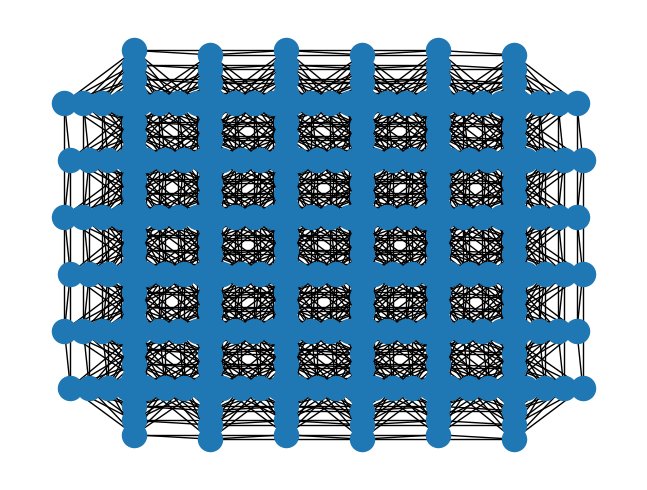

In [53]:
grid_shape = (12, 12)
dnx.draw_zephyr(G)

# Use BEFORE optimization:
G_clean = remove_edge_nodes(
        G_original, min_degree= 11)  # Adjust threshold as needed

# Use before optimization:
G_reduced = preprocess_graph(G_clean, V_target=144, H_target=32)

 # Step 1: Pixel-to-node assignment
pixel_to_node, node_to_pixel = assign_pixels_to_nodes_heuristic(
    G_reduced, num_pixels=V_target, grid_shape=grid_shape)
    
initial_visible_nodes = set(pixel_to_node.values())


# set targets
 
sol = build_and_solve(K=K, V_target=V_target, H_target=H_target, tee=True, initial_visible_assignment=pixel_to_node)
x_vals = sol["x"]
z_vals = sol["z"]
G_new = sol["G_original"]
print(x_vals)

In [32]:
# # STORING OPTIMIZATION RESULTS TO JSON
# import json

# def serialize_var_dict(var_dict):
#     out = {}
#     for k, v in var_dict.items():
#         # key can be Var, int, tuple, etc.
#         if hasattr(k, "name"):
#             key = k.name
#         else:
#             key = str(k)

#         # value can be numpy/scip
#         out[key] = float(v)
#     return out


# def serialize_graph(G):
#     return {
#         "nodes": list(G.nodes()),
#         "edges": [(u, v) for u, v in G.edges()]
#     }

# results = {
#     "variables": {
#         "x": serialize_var_dict(sol["x"]),
#         "y": serialize_var_dict(sol["y"]),
#         "z": serialize_var_dict(sol["z"]),
#         "u": serialize_var_dict(sol["u"]),
#         "t": float(sol["t"])
#     },
#     "objective_components": {
#         "c0": serialize_var_dict(sol["c0"]),
#         "losses": serialize_var_dict(sol["losses"]),
#         "c_eff": serialize_var_dict(sol["c_eff"])
#     },
#     "graphs": {
#         "original": serialize_graph(sol["G_original"]),
#         "contracted": serialize_graph(sol["G_contracted"])
#     },
#     "gap": 0.2
# }


# with open('K4_optimization_5400s_251217.json', 'w') as f:
#     json.dump(results, f, indent=4)

# print("Results saved to K4_optimization_5400s_251217.json")

In [54]:
G_fused, visible_nodes, hidden_nodes, clean_to_fused = apply_fusions_to_graph_clean(
    G_new, 
    x_vals, 
    z_vals,
)

# Stage 2: Greedy post-processing to reach exact target
G_contracted, visible_nodes, hidden_nodes = postprocess_fuse_hidden(
    G_fused, visible_nodes, hidden_nodes, H_target=32)


print(f"\nFinal result:")
print(f"  Visible: {len(visible_nodes)} (target: 144)")
print(f"  Hidden: {len(hidden_nodes)} (target: 32)")


=== Pre-Fusion Status ===
  Visible nodes: 144
  Hidden nodes: 192
  Fusions applied: 135

=== Relabeling to consecutive integers ===
  Relabeled nodes: 0 to 200
  Visible IDs: 0 to 143
  Hidden IDs: 144 to 200

=== POST-PROCESSING: Fuse 57 → 32 hidden nodes ===
  Progress: 10/25 fusions
  Progress: 20/25 fusions
✓ Post-processing complete:
  Visible: 144 (target: 144)
  Hidden: 32 (target: 32)
  Total nodes: 176

Final result:
  Visible: 144 (target: 144)
  Hidden: 32 (target: 32)


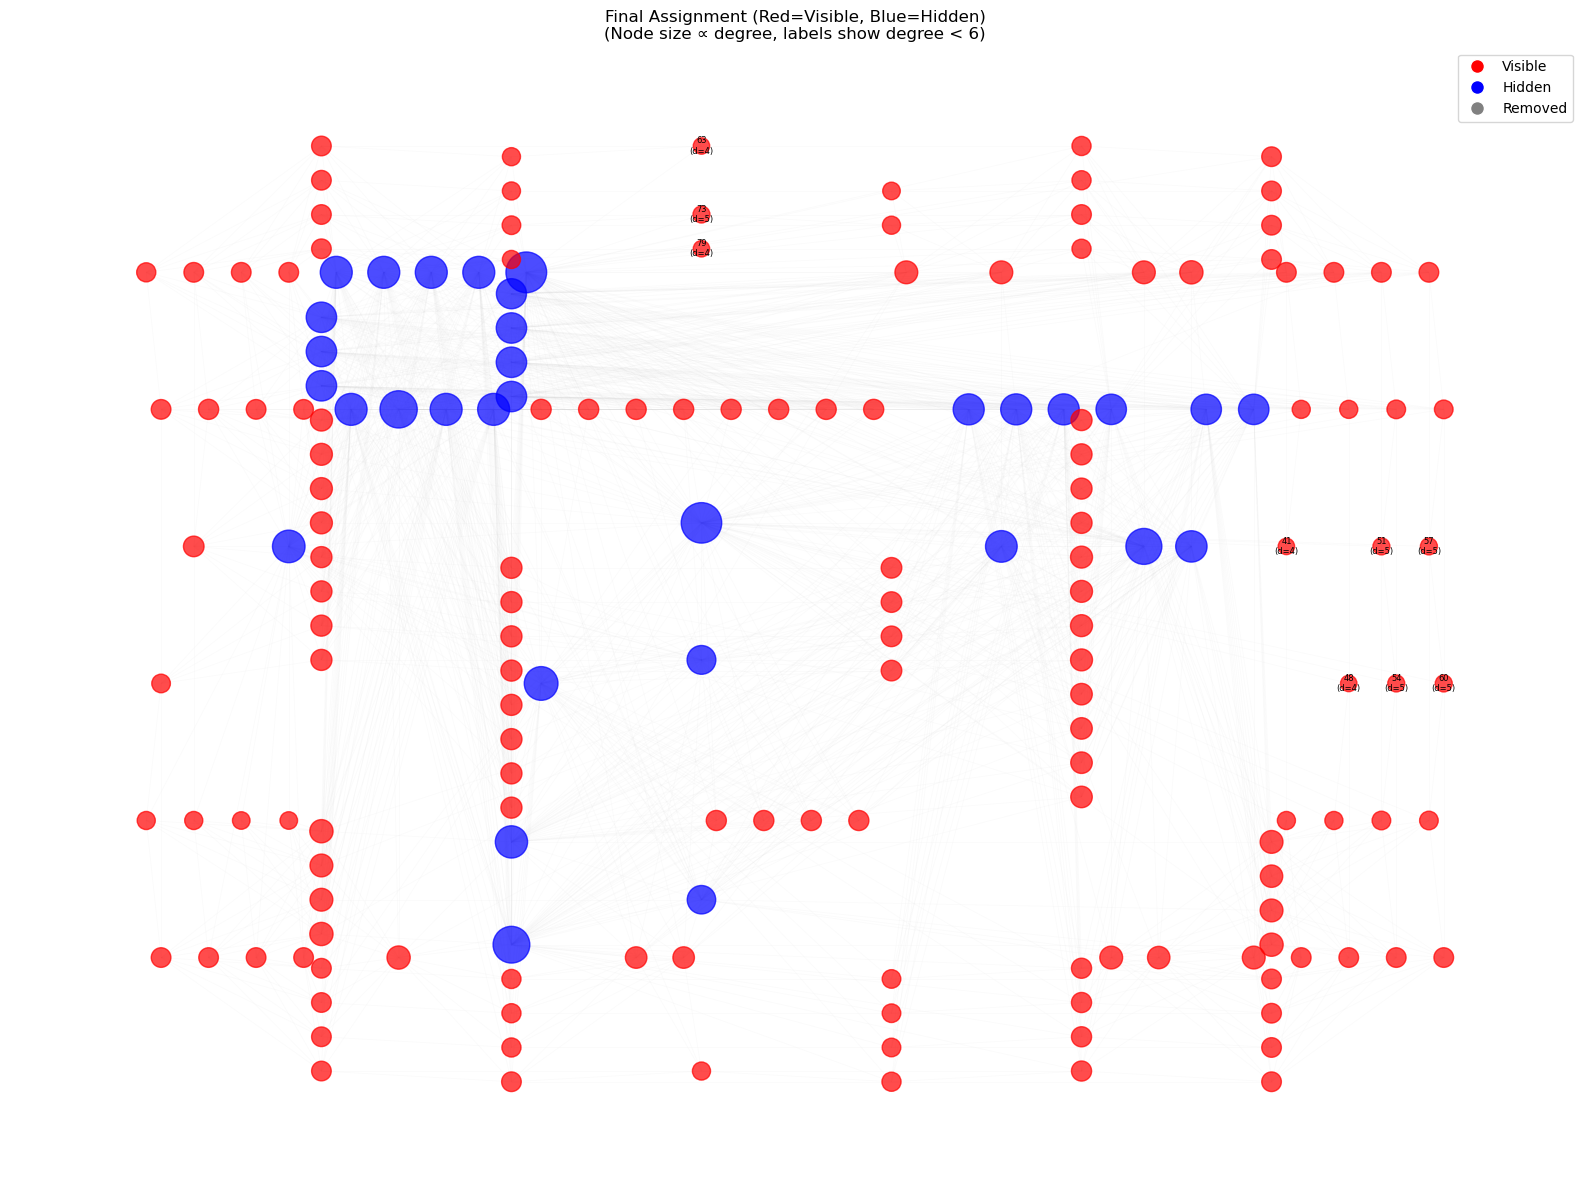

In [55]:
# After optimization and post-processing:
# G_contracted = G_fused
visualize_node_assignment_on_zephyr(G_contracted, visible_nodes, hidden_nodes, 
                                    title="Final Assignment (Red=Visible, Blue=Hidden)")

In [56]:


print(f"\nAfter fusion:")
print(f"  Original nodes: {sol['G_original'].number_of_nodes()}")
print(f"  Contracted nodes: {G_contracted.number_of_nodes()}")
print(f"  Visible: {len(visible_nodes)}")
print(f"  Hidden: {len(hidden_nodes)}")
print(f"  Expected hidden: {H_target}")

# 3. Relabel for training
G, visible_nodes, hidden_nodes, relabel_mapping = relabel_for_training(
    G_contracted, visible_nodes, hidden_nodes
)

print(f"\nRelabeled graph:")
print(f"  Visible node IDs: 0 to {len(visible_nodes)-1}")
print(f"  Hidden node IDs: {len(visible_nodes)} to {len(visible_nodes)+len(hidden_nodes)-1}")

# # Now use G_contracted as your G for the rest of the pipeline
# G = G_contracted

# 4. Create training structures
# Create vh_nodearray (1 for visible, 0 for hidden)
n = G.number_of_nodes()
vh_nodearray = np.zeros(n, dtype=int)

# Mark visible nodes as 1
for v in visible_nodes:
    vh_nodearray[v] = 1

# Create node_labels dictionary
node_labels = {i: ('visible' if vh_nodearray[i] == 1 else 'hidden') 
               for i in range(n)}

# Update global variables
NUM_VISIBLE = len(visible_nodes)
NUM_HIDDEN = len(hidden_nodes)

print(f"\n✓ Ready for training:")
print(f"  Total nodes: {n}")
print(f"  Visible nodes: {NUM_VISIBLE}")
print(f"  Hidden nodes: {NUM_HIDDEN}")
print(f"  vh_nodearray shape: {vh_nodearray.shape}")

# Annotate graph with layer info
for v in visible_nodes:
    G.nodes[v]["layer"] = "visible"
for h in hidden_nodes:
    G.nodes[h]["layer"] = "hidden"


After fusion:
  Original nodes: 336
  Contracted nodes: 176
  Visible: 144
  Hidden: 32
  Expected hidden: 32
Relabeling complete:
  Old node types: {'int'}
  New node IDs: all integers [0, 175]

Relabeled graph:
  Visible node IDs: 0 to 143
  Hidden node IDs: 144 to 175

✓ Ready for training:
  Total nodes: 176
  Visible nodes: 144
  Hidden nodes: 32
  vh_nodearray shape: (176,)


 Cross-edges (V-H): 886 out of 1495
 Visible nodes: 144
 Hidden nodes: 32


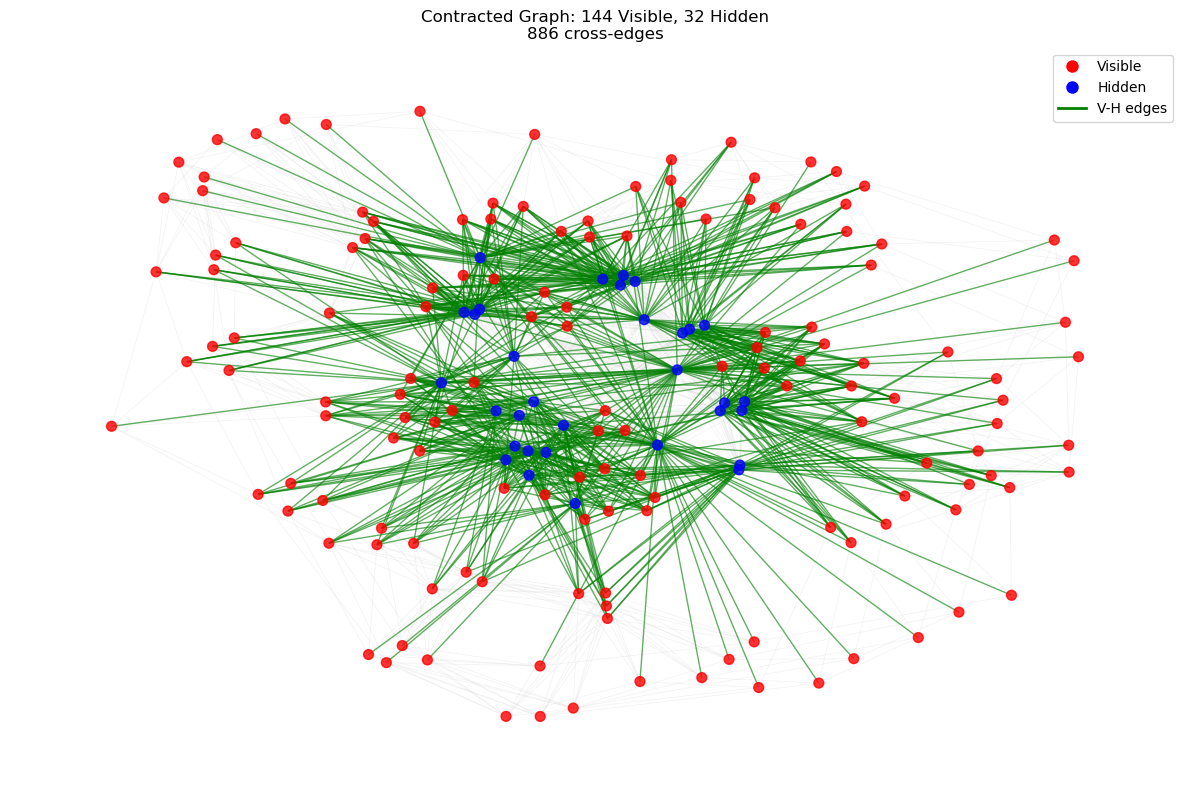

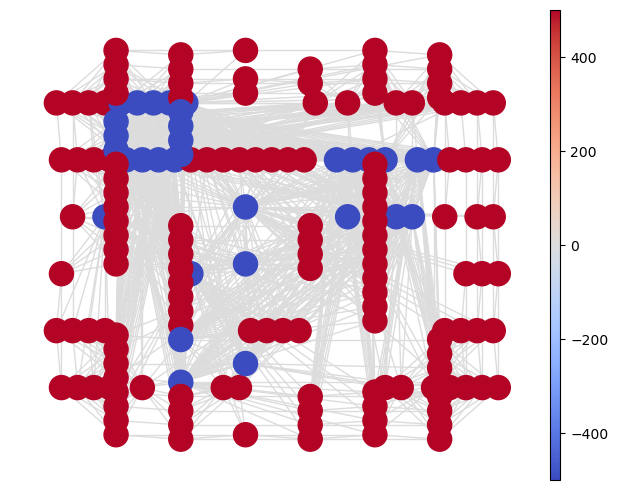

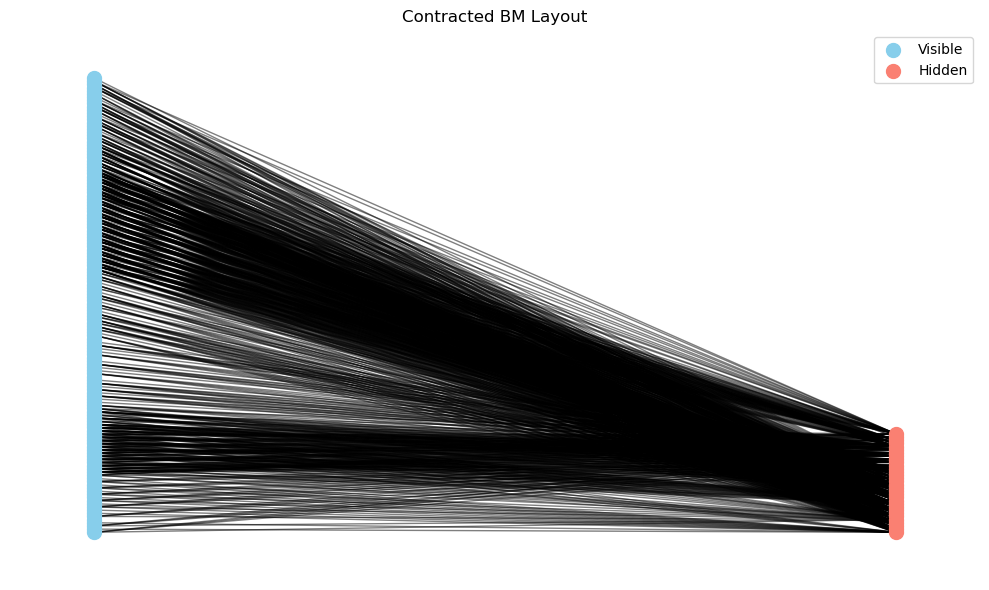

In [57]:
from bolmaqua import *
# Visualize the contracted, relabeled graph
x_sol = visualize_contracted_graph(G, visible_nodes, hidden_nodes, use_zephyr_layout=False)

# original Zephyr visualization (if it works with contracted graph)
try:
    draw_zephyr_hidden_visible(G, vh_nodearray)
except Exception as e:
    print(f"Note: Zephyr visualization doesn't work on contracted graph: {e}")


# Use the bipartite layout from your bolmaqua.py
visualize_bm_bipartite_layout(G, node_labels, title="Contracted BM Layout")

Loading dataset...
Found existing .\mnist12x12_trainfeats.npy and .\mnist12x12_trainlabels.npy.
Found existing .\mnist12x12_testfeats.npy and .\mnist12x12_testlabels.npy.
After flattening, X_data shape: torch.Size([200, 144])


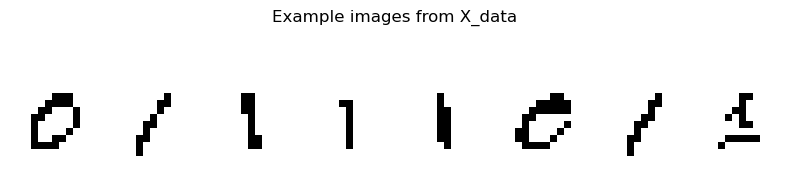

In [58]:

# --- Dataset Loading ---
# Using torchvision to download MNIST and then resize
def generate_downsized_mnist_torchvision(output_dir=".", grid_shape=GRID_SHAPE, cutoff=0.5):
    """
    Generates downsized MNIST .npy files (from torchvision MNIST, not CSV).
    Resizes 28x28 MNIST images to `grid_shape` (e.g., 12x12, 13x13).
    Saves features and labels as .npy for reuse.
    """
    os.makedirs(output_dir, exist_ok=True)

    def process_dataset(dataset, cutoff):
        downsized, labels = [], []
        for img, label in dataset:
            # torchvision MNIST returns a PIL image unless transform is ToTensor
            img_np = np.array(img, dtype=np.float32)

            # If shape is (28,28,1), squeeze it
            if img_np.ndim == 3:
                img_np = img_np.squeeze(-1)

            img_np = img_np / 255.0  # scale to [0,1]
            img_small = resize(img_np, grid_shape, order=1, anti_aliasing=True, preserve_range=True)

            img_bin = (img_small >= cutoff).astype(np.uint8)
            downsized.append(img_bin.flatten())
            labels.append(label)
        return np.array(downsized), np.array(labels)

    # Load MNIST from torchvision (downloads automatically if not present)
    train_data = datasets.MNIST(root="./data", train=True, download=True, transform=None)
    test_data  = datasets.MNIST(root="./data", train=False, download=True, transform=None)

    for split, dataset in [("train", train_data), ("test", test_data)]:
        out_feats = os.path.join(output_dir, f"mnist{grid_shape[0]}x{grid_shape[1]}_{split}feats.npy")
        out_labels = os.path.join(output_dir, f"mnist{grid_shape[0]}x{grid_shape[1]}_{split}labels.npy")
        if not (os.path.exists(out_feats) and os.path.exists(out_labels)):
            print(f"Generating {out_feats} and {out_labels}...")
            feats, labels = process_dataset(dataset, cutoff)
            print("Processed feats shape:", feats.shape) # Debug print
            np.save(out_feats, feats)
            np.save(out_labels, labels)
        else:
            print(f"Found existing {out_feats} and {out_labels}.")

    return (
        np.load(os.path.join(output_dir, f"mnist{grid_shape[0]}x{grid_shape[1]}_trainfeats.npy")),
        np.load(os.path.join(output_dir, f"mnist{grid_shape[0]}x{grid_shape[1]}_trainlabels.npy"))
    )



# --- Dataset Loading ---
print("Loading dataset...")
try:
    mnist_feats, mnist_labels = generate_downsized_mnist_torchvision(output_dir=".", grid_shape=GRID_SHAPE)
except FileNotFoundError as e:
    print("Error: Could not find MNIST CSVs. Falling back to synthetic data...")
    mnist_feats = np.random.rand(1000, NUM_VISIBLE) > 0.3
    mnist_feats = mnist_feats.astype(np.float32)
    mnist_labels = np.zeros(len(mnist_feats), dtype=np.float32)


# Only keep images with label 0 or 1
mnist_feats = mnist_feats[(mnist_labels == 0) | (mnist_labels == 1)]
mnist_labels = mnist_labels[(mnist_labels == 0) | (mnist_labels == 1)]


#cut size of dataset massively for faster training
num_images_to_use = 200
mnist_feats = mnist_feats[:num_images_to_use]  # Use only the first few images for quick testing
mnist_feats = (mnist_feats - mnist_feats.min()) / (mnist_feats.max() - mnist_feats.min())
# Binarize and create DataLoader
roundup_boost = 0
X_data = (torch.from_numpy(mnist_feats).float() < 0.5 + roundup_boost).float()
# Flatten from (N, 13, 13) → (N, 169)
if X_data.ndim == 3:
    X_data = X_data.view(X_data.shape[0], -1)

# Make sure shape is (num_samples, 169)
print("After flattening, X_data shape:", X_data.shape)

# Add labels explicitly, even if dummy, to avoid 1-tuple nesting
dummy_labels = torch.zeros(len(X_data))  
dataset = torch.utils.data.TensorDataset(X_data, dummy_labels)

# --- Visualize a few images from X_data ---
plt.figure(figsize=(8, 2))
for i in range(8):
    plt.subplot(1, 8, i + 1)
    plt.imshow(X_data[i].cpu().numpy().reshape(GRID_SHAPE), cmap='gray', vmin=0, vmax=1)
    plt.axis('off')
plt.suptitle("Example images from X_data")
plt.tight_layout()
plt.show()

In [59]:
# Create fresh node_labels dictionary
node_labels = {}
for node in G.nodes():
    if node in visible_nodes:
        node_labels[node] = 'visible'
    elif node in hidden_nodes:
        node_labels[node] = 'hidden'
    else:
        print(f"Warning: Node {node} not in visible or hidden lists!")
        node_labels[node] = 'hidden'  # Default to hidden

# Verify all nodes are covered
print(f"\n=== Node Label Check ===")
print(f"  Graph nodes: {G.number_of_nodes()}")
print(f"  Labeled nodes: {len(node_labels)}")
print(f"  Visible labeled: {sum(1 for v in node_labels.values() if v == 'visible')}")
print(f"  Hidden labeled: {sum(1 for v in node_labels.values() if v == 'hidden')}")

if set(G.nodes()) != set(node_labels.keys()):
    missing = set(G.nodes()) - set(node_labels.keys())
    extra = set(node_labels.keys()) - set(G.nodes())
    print(f" Mismatch detected!")
    print(f"    Missing from labels: {missing}")
    print(f"    Extra in labels: {extra}")
    raise ValueError("Graph nodes and node_labels keys don't match!")


=== Node Label Check ===
  Graph nodes: 176
  Labeled nodes: 176
  Visible labeled: 144
  Hidden labeled: 32


V-V edges: 344, H-H edges: 265, V-H edges: 886
Building Boltzmann Machine from graph... 🏗️
Sanity check:
  dataset feature dim: 144
  model num_visible   : 144
  model num_hidden    : 32
  W_vh shape (should be V x H): (144, 32)
Starting PCD training on cpu for 50 epochs... 🏋️
Epoch 1/50 | Avg PCD Loss: 0.0000 | PLL: -0.6362
Epoch 2/50 | Avg PCD Loss: 0.0000 | PLL: -0.5623
Epoch 3/50 | Avg PCD Loss: 0.0000 | PLL: -0.5421
Epoch 4/50 | Avg PCD Loss: 0.0000 | PLL: -0.4534
Epoch 5/50 | Avg PCD Loss: 0.0000 | PLL: -0.4210
Epoch 6/50 | Avg PCD Loss: 0.0000 | PLL: -0.3267
Epoch 7/50 | Avg PCD Loss: 0.0000 | PLL: -0.4020
Epoch 8/50 | Avg PCD Loss: 0.0000 | PLL: -0.3598
Epoch 9/50 | Avg PCD Loss: 0.0000 | PLL: -0.3690
Epoch 10/50 | Avg PCD Loss: 0.0000 | PLL: -0.3790
Epoch 11/50 | Avg PCD Loss: 0.0000 | PLL: -0.3404
Epoch 12/50 | Avg PCD Loss: 0.0000 | PLL: -0.3641
Epoch 13/50 | Avg PCD Loss: 0.0000 | PLL: -0.3063
Epoch 14/50 | Avg PCD Loss: 0.0000 | PLL: -0.2573
Epoch 15/50 | Avg PCD Loss: 0.0

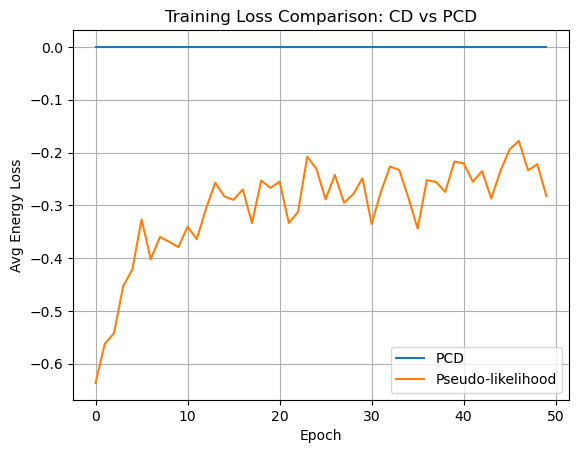

In [63]:
'''Hyperparameters here. 
num_gibbs_steps is an important addition, which determines 
how many gibbs steps are done for each sample in training
Increasing it increases training time linearly, unfortunately, 
and it is quite slow. '''
step_size = 0.002 # You can change this value for experiments 
l2_amount = 0.00175 # L2 regularization amount
num_epochs = 50
batch_size = 20
num_gibbs_steps = 150
data_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)



# # Print some graph statistics
# print(f"Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
# vv_edges = sum(1 for u, v in G.edges() if u < NUM_VISIBLE and v < NUM_VISIBLE)
# hh_edges = sum(1 for u, v in G.edges() if u >= NUM_VISIBLE and v >= NUM_VISIBLE)
# vh_edges = sum(1 for u, v in G.edges() if (u < NUM_VISIBLE) != (v < NUM_VISIBLE))
# print(f"V-V edges: {vv_edges}, H-H edges: {hh_edges}, V-H edges: {vh_edges}")

visible_set = set(visible_nodes)
hidden_set = set(hidden_nodes)

vv_edges = sum(1 for u, v in G.edges() if u in visible_set and v in visible_set)
hh_edges = sum(1 for u, v in G.edges() if u in hidden_set and v in hidden_set)
vh_edges = sum(1 for u, v in G.edges() if (u in visible_set) != (v in visible_set))

print(f"V-V edges: {vv_edges}, H-H edges: {hh_edges}, V-H edges: {vh_edges}")


# visualize_bm_bipartite_layout(G, node_labels, title="My Custom BM Layout (Bipartite Style)")


# Use the factory function
# model_cd = graph_to_bm(G, node_labels)
model_pcd = graph_to_bm(G, node_labels)


# Sanity check
print("Sanity check:")
print("  dataset feature dim:", X_data.shape[1])
print("  model num_visible   :", model_pcd.num_visible)
print("  model num_hidden    :", model_pcd.num_hidden)

# optional: ensure W_vh orientation (V x H)
W_vv, W_hh, W_vh = model_pcd._get_masked_weights()
W_vv.zero_() # disables v-v connections
print("  W_vh shape (should be V x H):", tuple(W_vh.shape))
assert W_vh.shape == (model_pcd.num_visible, model_pcd.num_hidden)


# --- Training ---
optimizer_pcd = torch.optim.Adam(model_pcd.parameters(), lr=step_size, weight_decay=l2_amount)
pcd_losses, pll_values = train_boltzmann_machine_pcd(model_pcd, data_loader, optimizer_pcd, num_epochs=num_epochs, k_steps=num_gibbs_steps, 
                                         batch_size=batch_size, step_size=step_size)

# check_fusion_strength(model_pcd, fused_pairs_remapped)
# --- Plot training loss ---
plt.plot(pcd_losses, label='PCD')
plt.plot(pll_values, label="Pseudo-likelihood")
plt.xlabel('Epoch')
plt.ylabel('Avg Energy Loss')
plt.title('Training Loss Comparison: CD vs PCD')
plt.legend()
plt.grid(True)
plt.show()

Running Gibbs sampler for 10 samples, 500 burn-in steps each... 🔥
  Gibbs sample 1/10
  Gibbs sample 2/10
  Gibbs sample 3/10
  Gibbs sample 4/10
  Gibbs sample 5/10
  Gibbs sample 6/10
  Gibbs sample 7/10
  Gibbs sample 8/10
  Gibbs sample 9/10
  Gibbs sample 10/10
Gibbs sampling complete.

Displaying generated images... 🖼️


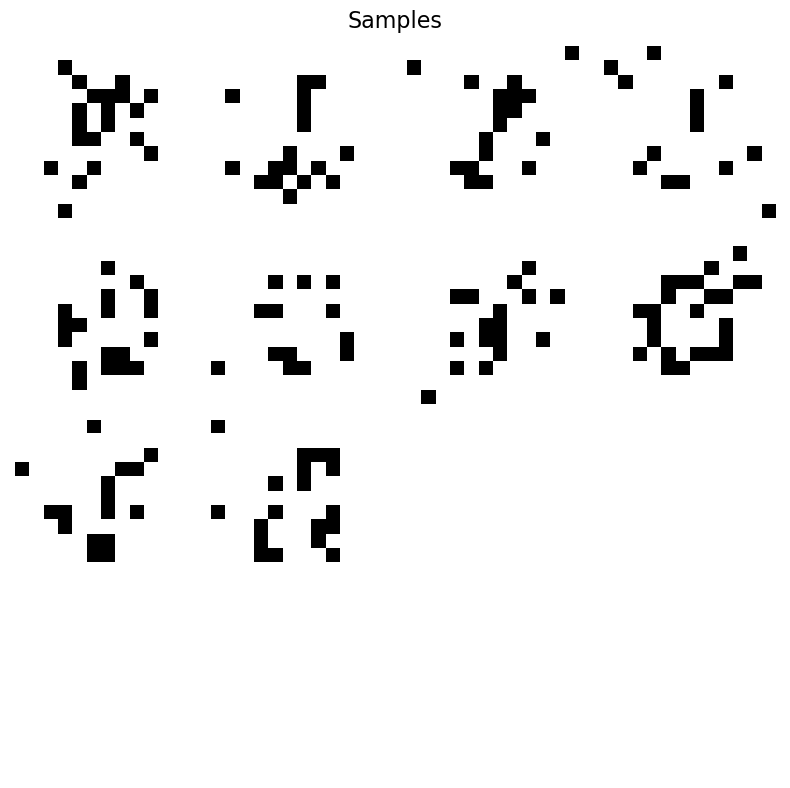

In [64]:
#--- Sampling & Visualization ---
num_gen_samples = 10
burn_in = 500


#need to find a way to speed up these sampling functions, so slow
samples_pcd = sample_from_bm(model_pcd, num_gen_samples, burn_in, method='gibbs')


def plot_samples(samples: torch.Tensor, title: str):
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        if i < samples.shape[0]:
            ax.imshow(samples[i].cpu().numpy().reshape(GRID_SHAPE), cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

print("\nDisplaying generated images... 🖼️")
plot_samples(samples_pcd, "Samples")


--- Improving samples with Tabu Search ---

Displaying Tabu Search improved images... 🖼️


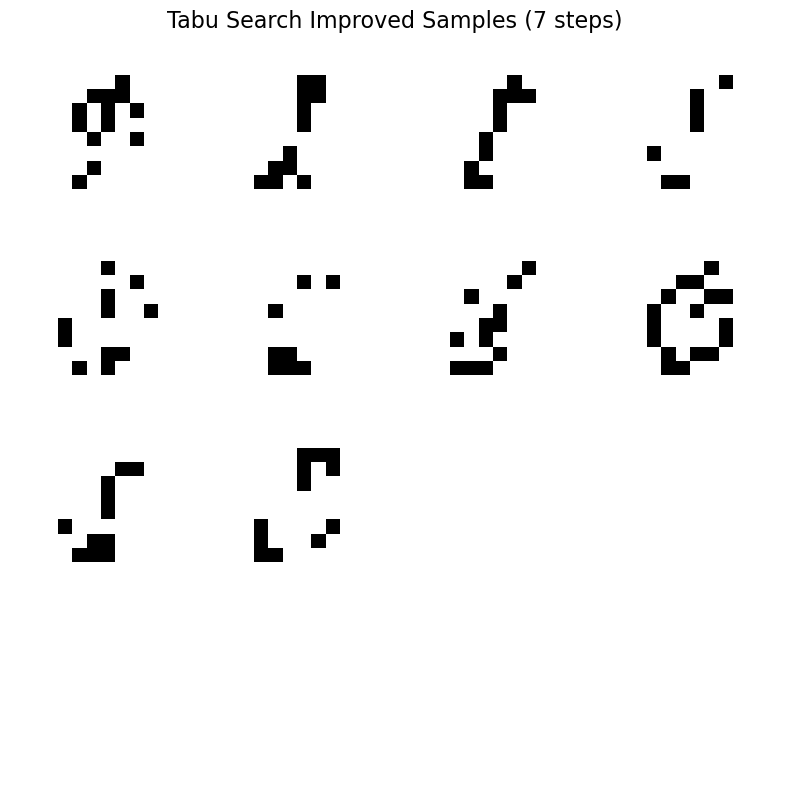

In [65]:
print("\n--- Improving samples with Tabu Search ---")
tabu_steps = 7
tabu_improved_samples = []
for i in range(samples_pcd.shape[0]):
    v_init = samples_pcd[i].unsqueeze(0)
    improved_v = tabu_search_bm(model_pcd, v_init, steps=tabu_steps)
    tabu_improved_samples.append(improved_v)
tabu_improved_samples = torch.stack(tabu_improved_samples, dim=0)

print("\nDisplaying Tabu Search improved images... 🖼️")
plot_samples(tabu_improved_samples, f"Tabu Search Improved Samples ({tabu_steps} steps)")